# 0)Preparacion de datos y funciones

In [3]:
import numpy as np
import jax.numpy as jnp

# Cargar los datos
datos = np.load("datos_3430.npz")

# Extraer las señales
X = jnp.array(datos['X'])

y = jnp.array(datos['y'])

print(f"Forma de los datos X: {X.shape}")
print(f"Forma de las etiquetas y: {y.shape}")

Forma de los datos X: (36, 256)
Forma de las etiquetas y: (36,)


In [8]:
def inicializar_aleatorio(key):
    key1, key2 = random.split(key)
    # Inicialización aleatoria estándar escalada para evitar saturación de la tanh
    W1 = random.normal(key1, (30, 256)) * jnp.sqrt(1.0 / 256.0)
    W2 = random.normal(key2, (256, 30)) * jnp.sqrt(1.0 / 30.0)
    return [W1, W2]

def inicializar_fourier(key):
    # Crear vector de tiempo normalizado t
    t = jnp.linspace(0, 1, 256, endpoint=False)

    # Crear vector de frecuencias k = 1, ..., 15
    k = jnp.arange(1, 16)

    # Vectorización: Expandir dimensiones para producto externo (15, 256)
    t_mat = t[None, :]  # Forma (1, 256)
    k_mat = k[:, None]  # Forma (15, 1)

    # Calcular senos y cosenos (Forma: 15x256 cada uno)
    senos = jnp.sin(2 * jnp.pi * k_mat * t_mat)
    cosenos = jnp.cos(2 * jnp.pi * k_mat * t_mat)

    # Apilar senos y cosenos para formar W1 (Forma: 30x256)
    W1 = jnp.vstack([senos, cosenos])

    # W2 se inicializa aleatoriamente en ambos casos
    _, key2 = random.split(key)
    W2 = random.normal(key2, (256, 30)) * jnp.sqrt(1.0 / 30.0)

    return [W1, W2]

In [9]:
@jit
def forward(params, x):
    W1, W2 = params
    # Asumiendo que 'x' entra como un batch de forma (N, 256)
    # W1.T tiene forma (256, 30), el resultado de x @ W1.T es (N, 30)
    z1 = jnp.dot(x, W1.T)
    a1 = jnp.tanh(z1)
    # W2.T tiene forma (30, 256), el resultado de a1 @ W2.T es (N, 256)
    x_hat = jnp.dot(a1, W2.T)
    return x_hat

@jit
def loss_fn(params, x):
    x_hat = forward(params, x)
    # Media cuadrática del error
    return jnp.mean((x_hat - x)**2)

@jit
def update(params, x, lr):
    # Calcula el valor de la pérdida y los gradientes respecto a 'params'
    loss, grads = jax.value_and_grad(loss_fn)(params, x)

    # Actualización de Descenso de Gradiente
    new_params = [p - lr * g for p, g in zip(params, grads)]
    return new_params, loss

In [ ]:
def entrenar_red(params_iniciales, datos_x, iteraciones=4000, lr=0.02):
    params = params_iniciales
    historial_loss = []

    for i in range(iteraciones):
        params, loss = update(params, datos_x, lr)
        historial_loss.append(loss)

        if (i + 1) % 500 == 0:
            print(f"Iteración {i+1}/{iteraciones} | Loss: {loss:.6f}")

    return params, historial_loss

# Generamos las semillas para la aleatoriedad
key = random.PRNGKey(42)

# 1. Entrenar con inicialización Aleatoria
print("--- Entrenando con Inicialización Aleatoria ---")
params_rand = inicializar_aleatorio(key)
params_rand_final, loss_rand = entrenar_red(params_rand, X)

# 2. Entrenar con inicialización de Fourier
print("\n--- Entrenando con Inicialización de Fourier ---")
params_fourier = inicializar_fourier(key)
params_fourier_final, loss_fourier = entrenar_red(params_fourier, X)

#1)Capa Fourier

In [21]:
# --- Evidencia Capa Fourier vs np.fft ---

# Tomamos una señal cualquiera del dataset para la prueba
x_prueba = X[0]
W1_fourier, _ = inicializar_fourier(key)

# 1. Proyección manual con nuestra capa W1 (tamaño 30x256)
# Esto da 30 valores: los primeros 15 son proyecciones de senos, los siguientes 15 de cosenos
coefs_W1 = jnp.dot(W1_fourier, x_prueba)
senos_W1 = coefs_W1[:15]
cosenos_W1 = coefs_W1[15:]

# 2. Transformada con jax.numpy.fft (equivalente a np.fft)
# Usamos rfft porque la señal es real. Esto nos da coeficientes complejos.
fft_oficial = jnp.fft.rfft(x_prueba)

# Descartamos la frecuencia 0 (índice 0) y tomamos las frecuencias k=1 hasta 15
fft_k1_15 = fft_oficial[1:16]

# La energía de una señal discreta suele definirse como la suma o el promedio de sus valores al cuadrado.
energia_media = jnp.mean(X**2)
print(f"La energía media del dataset es: {energia_media:.3f}")


# Comparamos visualmente las magnitudes de los primeros 5 coeficientes:
print("Comparación de coeficientes (Primeras 5 frecuencias):")
print(f"Cosenos W1:        {cosenos_W1[:5]}")
print(f"Parte Real FFT:    {jnp.real(fft_k1_15[:5])}")
print("-" * 40)
print(f"Senos W1:          {senos_W1[:5]}")
print(f"Parte Imag FFT:    {-jnp.imag(fft_k1_15[:5])}") # Signo depende de la convención de FFT

La energía media del dataset es: 0.679
Comparación de coeficientes (Primeras 5 frecuencias):
Cosenos W1:        [4.0157332 3.5246873 4.1735125 4.098498  4.2274184]
Parte Real FFT:    [4.015732  3.5246866 4.1735125 4.0984993 4.227418 ]
----------------------------------------
Senos W1:          [0.5023209 0.4409555 1.3556108 1.1687545 1.6784571]
Parte Imag FFT:    [0.5023185  0.44095623 1.3556118  1.1687549  1.6784587 ]


Pedimos la salida de np.fft de una sola señal para verificar la inicialización. La capa $W_1$ emula esto al separar explícitamente el cálculo en componentes reales (senos y cosenos)

Se pide la energía media porque nos da un punto de referencia de la "magnitud" de la información. Si el error de reconstrucción es comparable o mayor a la energía de la señal original, la red no está aprendiendo nada útil

# 2)Entrenamiento y reconstrucción

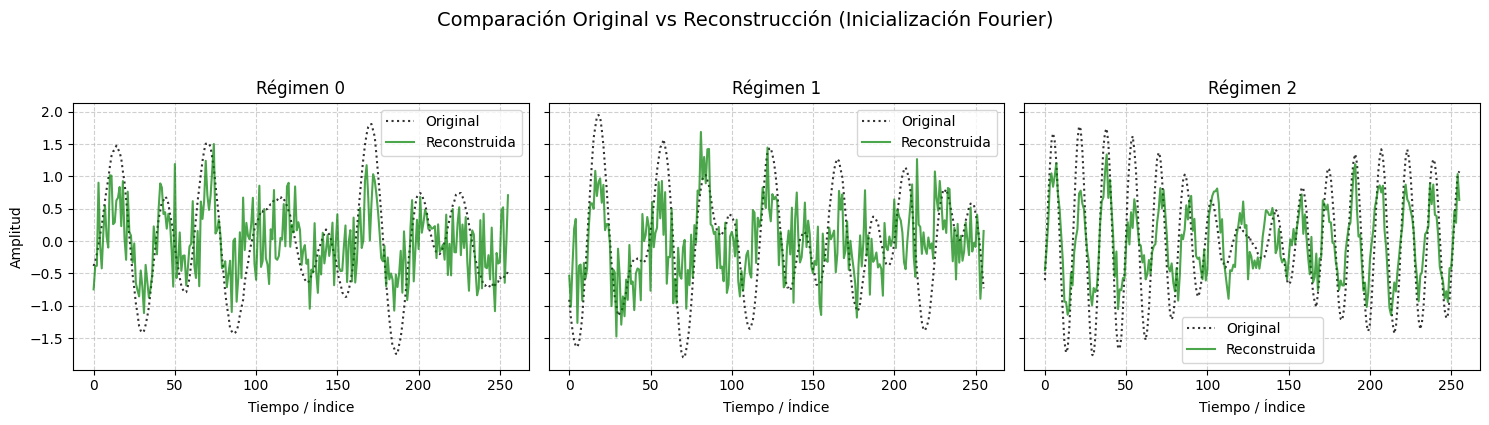

In [19]:
regimenes = jnp.unique(y)

# Crear una figura con subgráficos para cada régimen
fig, axes = plt.subplots(1, len(regimenes), figsize=(15, 4), sharey=True)

for i, reg in enumerate(regimenes):
    # Obtener el índice de la primera señal que pertenezca a este régimen
    idx = jnp.where(y == reg)[0][0]
    x_orig = X[idx]

    # Hacer el forward pass para obtener la reconstrucción (usamos la red de Fourier como ejemplo)
    # Se pasa x_orig[None, :] para mantener la forma (1, 256) que espera la red
    x_recon = forward(params_fourier_final, x_orig[None, :])[0]

    # Graficar
    axes[i].plot(x_orig, label='Original', color='black', alpha=0.8, linestyle=':')
    axes[i].plot(x_recon, label='Reconstruida', color='green', alpha=0.7)
    axes[i].set_title(f"Régimen {reg}", fontsize=12)
    axes[i].set_xlabel("Tiempo / Índice")
    axes[i].grid(True, linestyle='--', alpha=0.6)
    axes[i].legend()

axes[0].set_ylabel("Amplitud")
plt.suptitle("Comparación Original vs Reconstrucción (Inicialización Fourier)", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

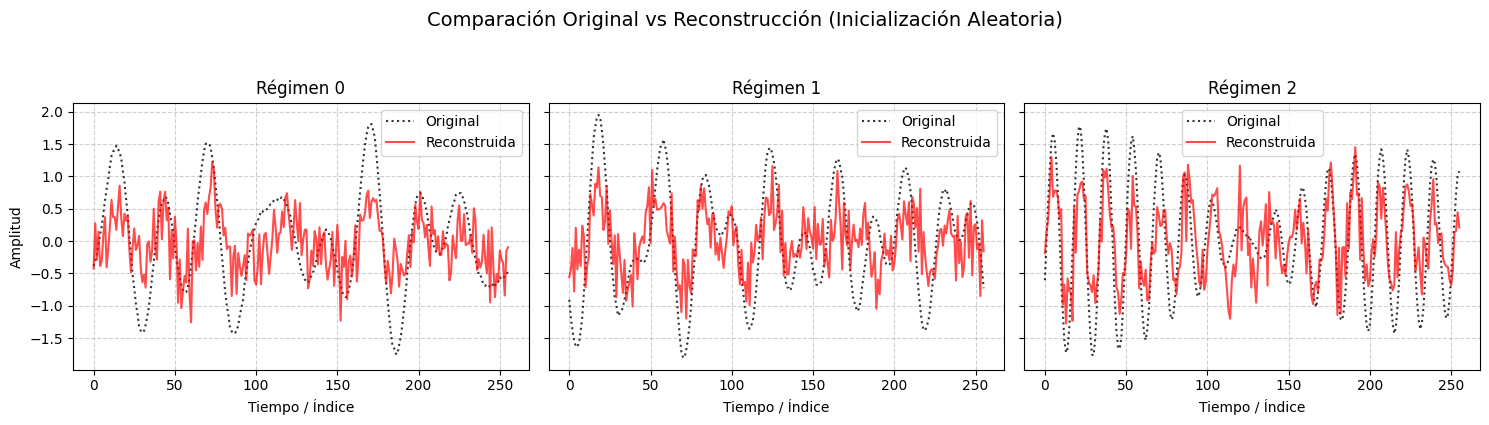

In [20]:
regimenes = jnp.unique(y)

# Crear una figura con subgráficos para cada régimen
fig, axes = plt.subplots(1, len(regimenes), figsize=(15, 4), sharey=True)

for i, reg in enumerate(regimenes):
    # Obtener el índice de la primera señal que pertenezca a este régimen
    idx = jnp.where(y == reg)[0][0]
    x_orig = X[idx]

    # Hacer el forward pass para obtener la reconstrucción (usamos la red de inicialización aleatoria)
    # Se pasa x_orig[None, :] para mantener la forma (1, 256) que espera la red
    x_recon = forward(params_rand_final, x_orig[None, :])[0]

    # Graficar
    axes[i].plot(x_orig, label='Original', color='black', alpha=0.8, linestyle=':')
    axes[i].plot(x_recon, label='Reconstruida', color='red', alpha=0.7)
    axes[i].set_title(f"Régimen {reg}", fontsize=12)
    axes[i].set_xlabel("Tiempo / Índice")
    axes[i].grid(True, linestyle='--', alpha=0.6)
    axes[i].legend()

axes[0].set_ylabel("Amplitud")
plt.suptitle("Comparación Original vs Reconstrucción (Inicialización Aleatoria)", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

In [15]:
# --- Error de Reconstrucción Relativo ---

def error_relativo(x_real, x_pred):
    # Calculamos la norma a lo largo del eje 1 (las 256 características de la señal)
    norma_diferencia = jnp.linalg.norm(x_pred - x_real, axis=1)
    norma_original = jnp.linalg.norm(x_real, axis=1)

    # Retornamos el promedio del error relativo de todas las señales
    return jnp.mean(norma_diferencia / norma_original)

# Calcular predicciones para todo el dataset con ambas redes
x_hat_fourier = forward(params_fourier_final, X)
x_hat_rand = forward(params_rand_final, X)

# Calcular y reportar los errores
err_rel_fourier = error_relativo(X, x_hat_fourier)
err_rel_rand = error_relativo(X, x_hat_rand)

print("Error de Reconstrucción Relativo Promedio:")
print(f" - Inicialización Fourier:  {err_rel_fourier:.4f}")
print(f" - Inicialización Aleatoria: {err_rel_rand:.4f}")

Error de Reconstrucción Relativo Promedio:
 - Inicialización Fourier:  0.8072
 - Inicialización Aleatoria: 0.7719


Idealmente, el error debe reportarse sobre un conjunto de validación (datos que la red no vio al entrenar) para medir la generalización. Sin embargo, en un autoencoder básico de compresión, evaluarlo sobre el set de entrenamiento nos dice qué tan bien logró comprimir y descomprimir esa información específica. La diferencia de errores entre ambas parametrizaciones nos demuestra empíricamente si inyectar conocimiento del dominio (la base de Fourier) mejora la capacidad representacional de la red frente a arrancar a ciegas.

#Comparación de inicializaciones

In [22]:
# --- Actualización del ciclo de entrenamiento ---

@jit
def calcular_error_relativo(params, x):
    x_hat = forward(params, x)
    norma_dif = jnp.linalg.norm(x_hat - x, axis=1)
    norma_orig = jnp.linalg.norm(x, axis=1)
    return jnp.mean(norma_dif / norma_orig)

def entrenar_red_avanzado(params_iniciales, X_total, y_total, iteraciones=4000, lr=0.02):
    params = params_iniciales

    # Identificar índices del Régimen 1 (asumiendo que la etiqueta es 1, ajusta si es 0 u otra)
    idx_reg1 = jnp.where(y_total == 1)[0]
    X_reg1 = X_total[idx_reg1]

    historial = {
        'loss_total': [],
        'err_rel_total': [],
        'loss_reg1': []
    }

    for i in range(iteraciones):
        # Actualización usando todos los datos
        params, loss = update(params, X_total, lr)

        # Guardar métricas
        err_rel = calcular_error_relativo(params, X_total)
        loss_r1 = loss_fn(params, X_reg1) # Pérdida solo para el régimen 1

        historial['loss_total'].append(loss)
        historial['err_rel_total'].append(err_rel)
        historial['loss_reg1'].append(loss_r1)

    return params, historial

# Volvemos a entrenar usando la nueva función
print("Entrenando Inicialización Aleatoria...")
params_rand_final, hist_rand = entrenar_red_avanzado(params_rand, X, y)

print("Entrenando Inicialización Fourier...")
params_fourier_final, hist_fourier = entrenar_red_avanzado(params_fourier, X, y)

Entrenando Inicialización Aleatoria...
Entrenando Inicialización Fourier...


Iteraciones para alcanzar Error Relativo < 0.1:
 - Base Fourier: No alcanzó el umbral
 - Base Aleatoria: No alcanzó el umbral


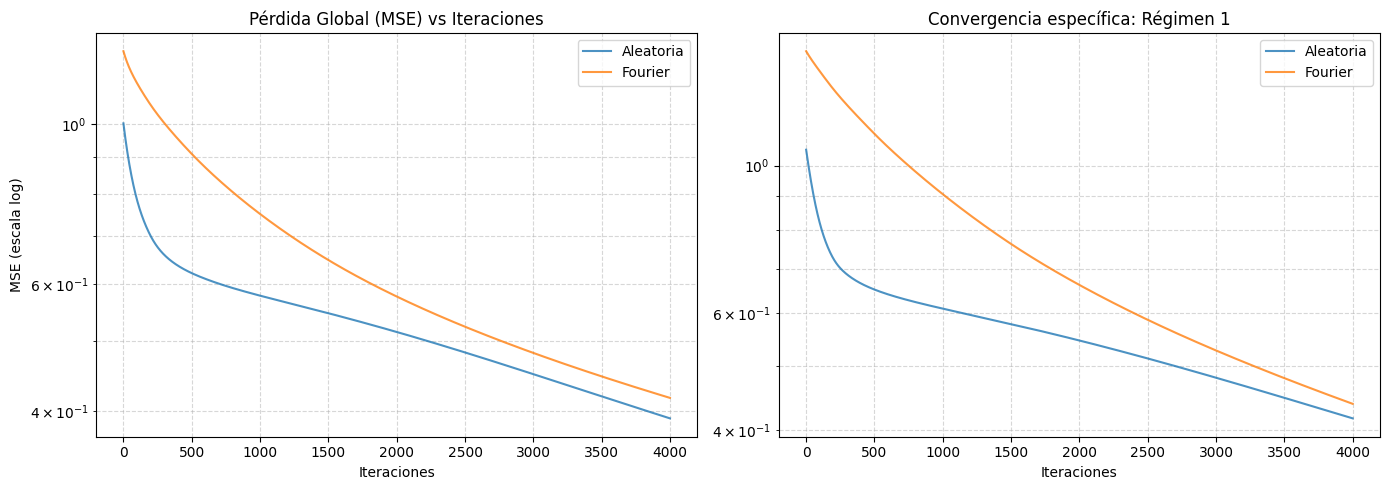

In [23]:
# --- Medición de iteraciones para Error Relativo < 0.1 ---

def iteraciones_para_umbral(historial_err, umbral=0.1):
    # np.where devuelve los índices donde se cumple la condición
    indices = np.where(np.array(historial_err) < umbral)[0]
    if len(indices) > 0:
        return indices[0] + 1 # +1 porque los índices empiezan en 0
    return "No alcanzó el umbral"

iter_fourier = iteraciones_para_umbral(hist_fourier['err_rel_total'], 0.1)
iter_rand = iteraciones_para_umbral(hist_rand['err_rel_total'], 0.1)

print(f"Iteraciones para alcanzar Error Relativo < 0.1:")
print(f" - Base Fourier: {iter_fourier}")
print(f" - Base Aleatoria: {iter_rand}")


# --- Gráfica 1: Pérdida vs Iteraciones (Global y Régimen 1) ---

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Pérdida Global
ax1.plot(hist_rand['loss_total'], label='Aleatoria', alpha=0.8)
ax1.plot(hist_fourier['loss_total'], label='Fourier', alpha=0.8)
ax1.set_yscale('log')
ax1.set_title("Pérdida Global (MSE) vs Iteraciones")
ax1.set_xlabel("Iteraciones")
ax1.set_ylabel("MSE (escala log)")
ax1.grid(True, which="both", ls="--", alpha=0.5)
ax1.legend()

# Subplot 2: Pérdida Régimen 1 (Contraste de convergencia)
ax2.plot(hist_rand['loss_reg1'], label='Aleatoria', alpha=0.8)
ax2.plot(hist_fourier['loss_reg1'], label='Fourier', alpha=0.8)
ax2.set_yscale('log')
ax2.set_title("Convergencia específica: Régimen 1")
ax2.set_xlabel("Iteraciones")
ax2.grid(True, which="both", ls="--", alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.show()

El primer gráfico responde a la curva de pérdida general de las dos inicializaciones superpuestas. El segundo contrasta la velocidad de convergencia específicamente para el Régimen 1

Coeficientes necesarios para el 85% de la energía: 2 de 30


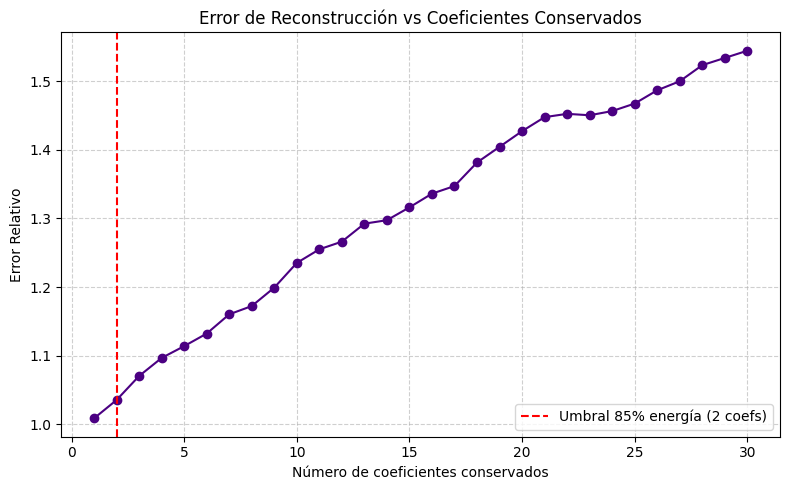

In [24]:
# --- Análisis de Compresión y Energía (Capa Fourier) ---

# Usamos los pesos iniciales de Fourier (antes de entrenar) para ver
# cómo distribuyen la energía naturalmente.
W1_f, W2_f = inicializar_fourier(key)

# Tomamos una señal promedio o una señal específica (ej. la primera)
x_test = X[0]

# Calculamos los 30 coeficientes de la capa oculta (proyección lineal)
coeficientes = jnp.dot(W1_f, x_test)

# La energía de cada coeficiente es su valor al cuadrado
energia_coeficientes = coeficientes**2

# Ordenamos los coeficientes por su energía de mayor a menor
indices_ordenados = jnp.argsort(energia_coeficientes)[::-1]
energia_ordenada = energia_coeficientes[indices_ordenados]

# Calculamos la energía acumulada y la normalizamos (de 0 a 1)
energia_total = jnp.sum(energia_ordenada)
energia_acumulada_relativa = jnp.cumsum(energia_ordenada) / energia_total

# Encontrar cuántos coeficientes se necesitan para el 85% (0.85)
num_coefs_85 = jnp.where(energia_acumulada_relativa >= 0.85)[0][0] + 1
print(f"Coeficientes necesarios para el 85% de la energía: {num_coefs_85} de 30")


# --- Gráfica 2: Error de reconstrucción vs Coeficientes conservados ---

errores_compresion = []
# Evaluamos reteniendo desde 1 hasta los 30 coeficientes
for n in range(1, 31):
    # Crear una máscara de ceros
    coeficientes_comprimidos = jnp.zeros_like(coeficientes)

    # Mantener solo los 'n' coeficientes más importantes (con más energía)
    indices_a_mantener = indices_ordenados[:n]
    coeficientes_comprimidos = coeficientes_comprimidos.at[indices_a_mantener].set(coeficientes[indices_a_mantener])

    # Reconstruir la señal pasando por la tanh y la segunda capa (W2)
    a1_comprimido = jnp.tanh(coeficientes_comprimidos)
    x_reconstruida = jnp.dot(a1_comprimido, W2_f.T)

    # Calcular el error relativo para esta compresión
    err = jnp.linalg.norm(x_reconstruida - x_test) / jnp.linalg.norm(x_test)
    errores_compresion.append(err)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 31), errores_compresion, marker='o', linestyle='-', color='indigo')
plt.axvline(x=num_coefs_85, color='red', linestyle='--', label=f'Umbral 85% energía ({num_coefs_85} coefs)')
plt.title("Error de Reconstrucción vs Coeficientes Conservados")
plt.xlabel("Número de coeficientes conservados")
plt.ylabel("Error Relativo")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

El análisis de compresión demuestra que la transformada de Fourier concentra la mayor parte de la energía (información) de la señal en las frecuencias principales (bajas). Al ordenar los coeficientes por magnitud, podemos descartar aquellos con valores cercanos a cero sin que el error de reconstrucción sufra un aumento drástico, logrando el umbral del 85% de la energía conservando solo una fracción de las 30 neuronas disponibles.